In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer


## Loading Dataset : ( Smartphone Usage Dataset )

In [2]:
Original_Data = pd.read_csv("Smartphone_Usage_Addiction.csv")
df = Original_Data.copy()

df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


## Basic Info :

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


## EDA : ( Exloratory Data Analysis )

### Univariate Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9760\3886812210.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='academic_work_impact', data=df, palette='Set2', ax=axes[2,0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9760\3886812210.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='addiction_level', data=df, palette='coolwarm', ax=axes[2,1])


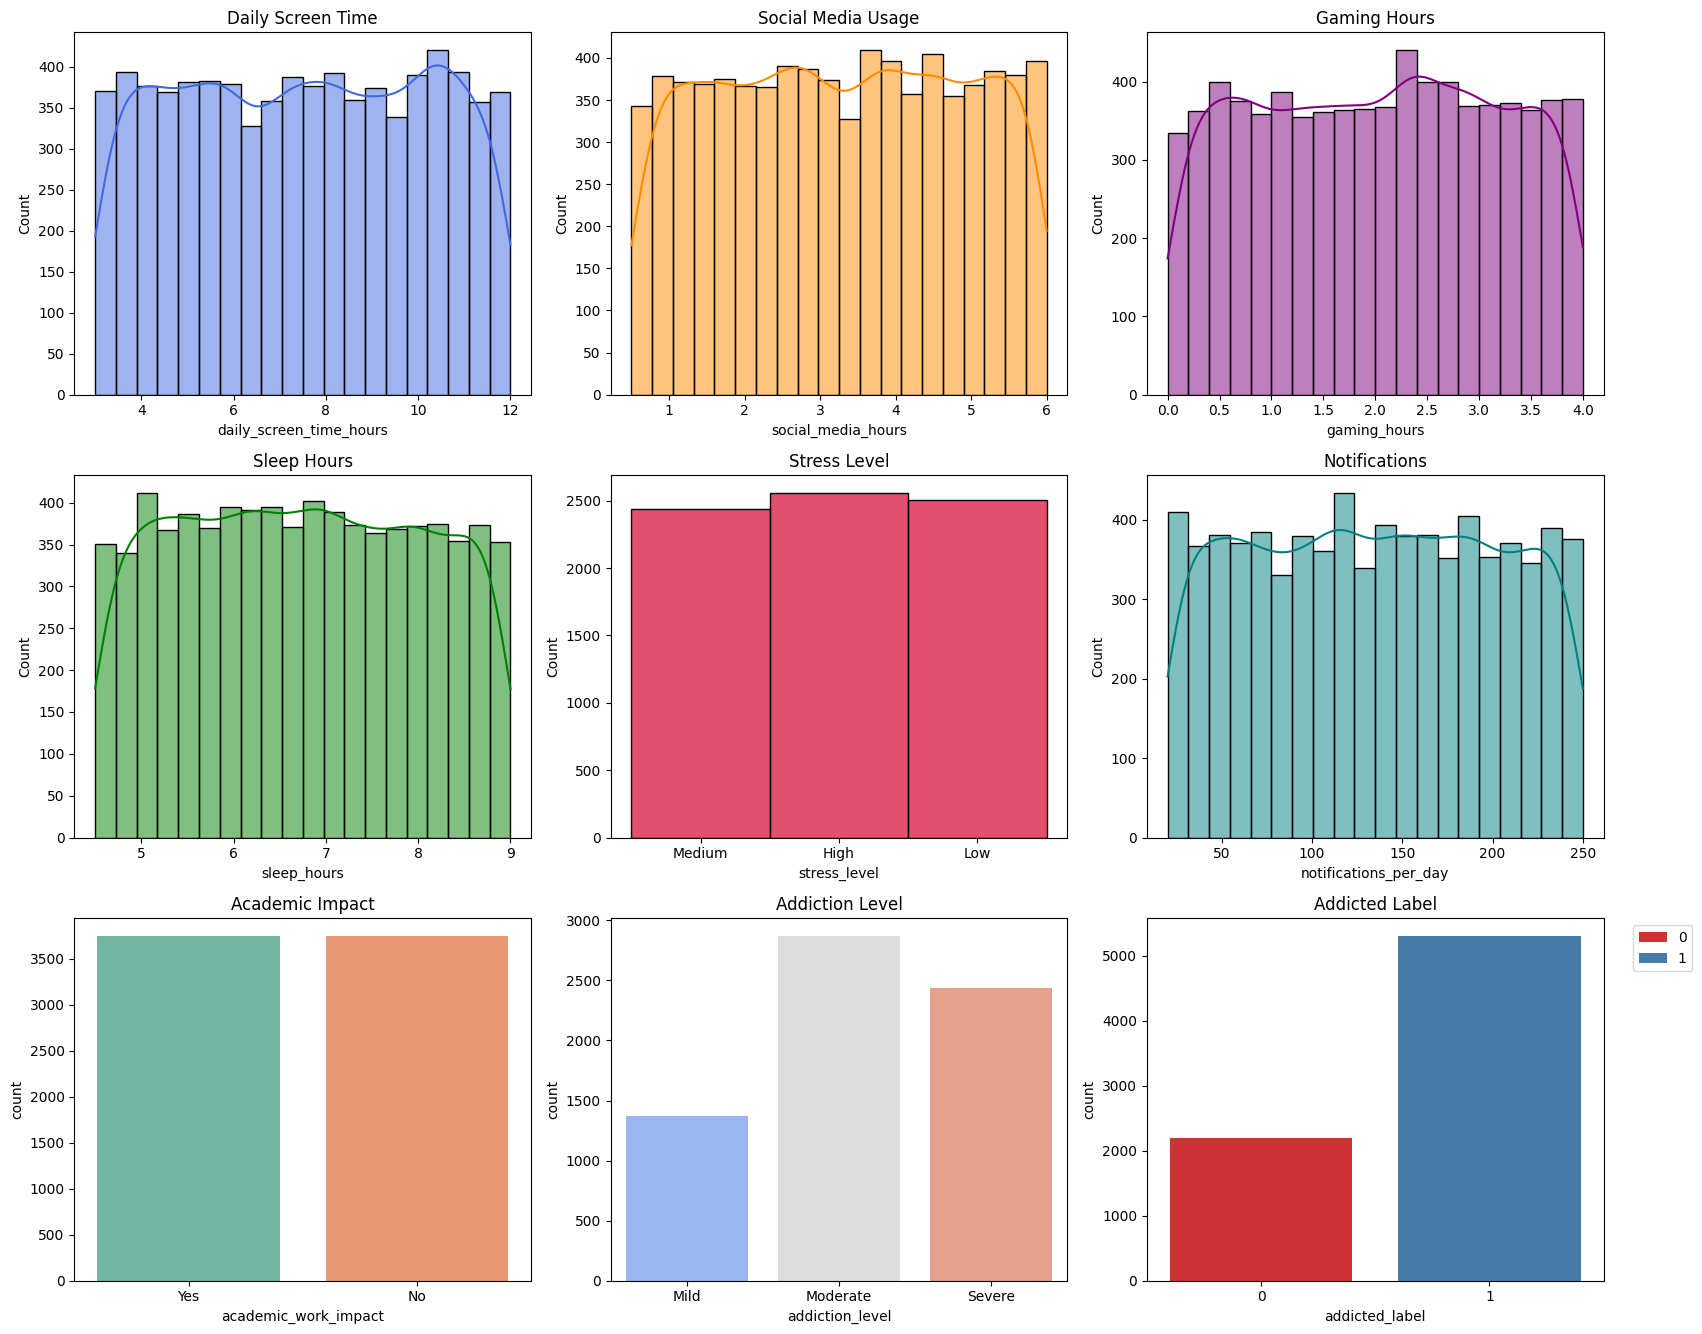

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

sns.histplot(df['daily_screen_time_hours'], kde=True, color='royalblue', ax=axes[0,0])
axes[0,0].set_title("Daily Screen Time")

sns.histplot(df['social_media_hours'], kde=True, color='darkorange', ax=axes[0,1])
axes[0,1].set_title("Social Media Usage")

sns.histplot(df['gaming_hours'], kde=True, color='purple', ax=axes[0,2])
axes[0,2].set_title("Gaming Hours")

sns.histplot(df['sleep_hours'], kde=True, color='green', ax=axes[1,0])
axes[1,0].set_title("Sleep Hours")

sns.histplot(df['stress_level'], color='crimson', ax=axes[1,1])
axes[1,1].set_title("Stress Level")

sns.histplot(df['notifications_per_day'], kde=True, color='teal', ax=axes[1,2])
axes[1,2].set_title("Notifications")

sns.countplot(x='academic_work_impact', data=df, palette='Set2', ax=axes[2,0])
axes[2,0].set_title("Academic Impact")

sns.countplot(x='addiction_level', data=df, palette='coolwarm', ax=axes[2,1])
axes[2,1].set_title("Addiction Level")

sns.countplot(x='addicted_label', hue='addicted_label',
              data=df, palette='Set1', ax=axes[2,2])
axes[2,2].set_title("Addicted Label")
axes[2,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()


### Bivariate Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9760\3902491993.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='addicted_label', y='daily_screen_time_hours',
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9760\3902491993.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='addicted_label', y='sleep_hours',
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9760\3902491993.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='addicted_label', y='stress_level',


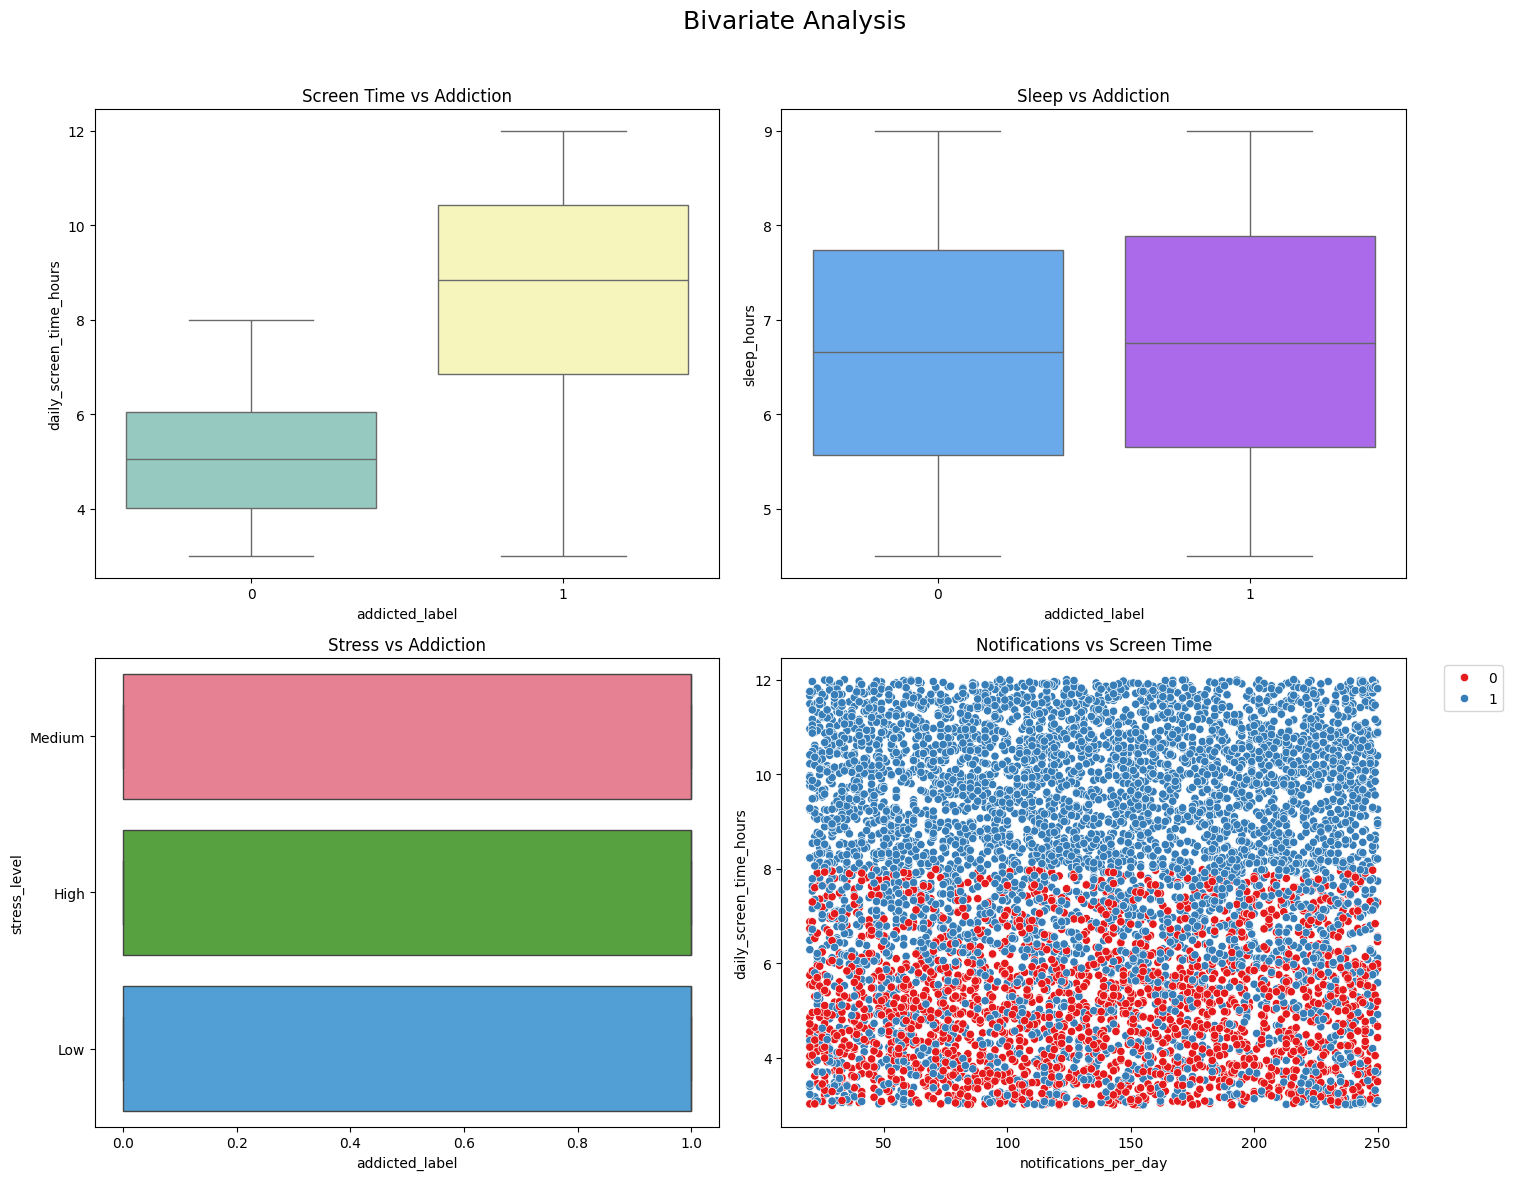

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Bivariate Analysis", fontsize=18)

sns.boxplot(x='addicted_label', y='daily_screen_time_hours',
            data=df, palette='Set3', ax=axes[0,0])
axes[0,0].set_title("Screen Time vs Addiction")

sns.boxplot(x='addicted_label', y='sleep_hours',
            data=df, palette='cool', ax=axes[0,1])
axes[0,1].set_title("Sleep vs Addiction")

sns.boxplot(x='addicted_label', y='stress_level',
            data=df, palette='husl', ax=axes[1,0])
axes[1,0].set_title("Stress vs Addiction")

sns.scatterplot(x='notifications_per_day', y='daily_screen_time_hours',
                hue='addicted_label', palette='Set1',
                data=df, ax=axes[1,1])
axes[1,1].set_title("Notifications vs Screen Time")
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()

### Multivariate Analysis

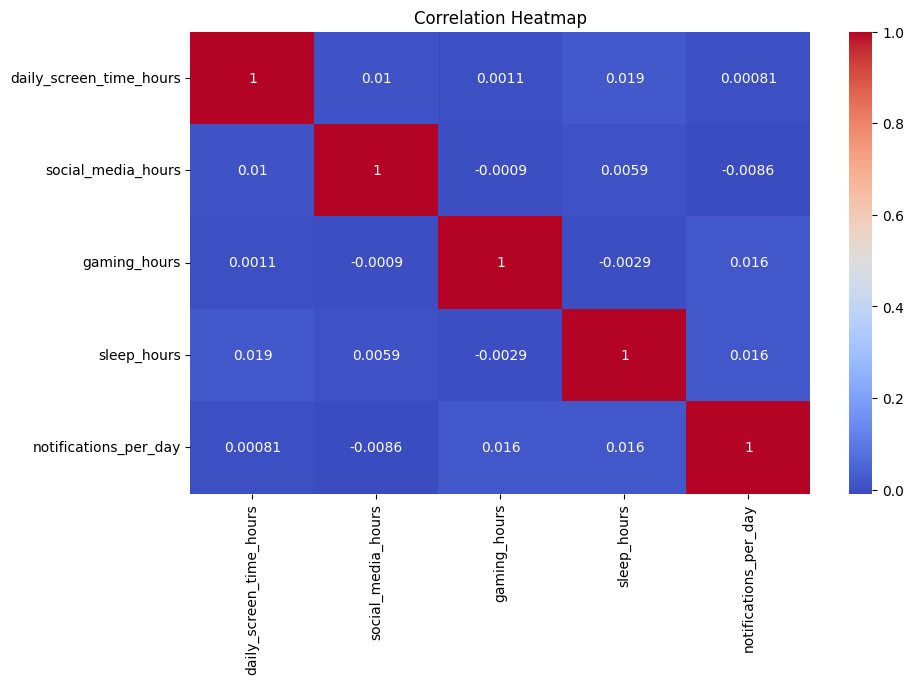

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['daily_screen_time_hours','social_media_hours',
                'gaming_hours','sleep_hours','notifications_per_day']].corr(),
            annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Missing Value Identification :

In [ ]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df))*100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage(%)':missing_percent 
})

missing_df

## Dropping Unnecessary Feature :

In [ ]:
df = df.drop(columns=['transaction_id'])
df = df.drop(columns=['user_id'])

In [ ]:
df.dtypes

## Missing Value Imputation :

In [ ]:
def random_impute(col):

    values = col.dropna().values
    
    return col.apply(lambda x: np.random.choice(values) if pd.isna(x) else x)

df['addiction_level'] = random_impute(df['addiction_level'])

In [ ]:
df.isnull().sum()

In [ ]:
df

## Checking Distribution :

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['daily_screen_time_hours'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Daily Screen Distribution')

sns.histplot(df['social_media_hours'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Social Media Distribution')

sns.histplot(df['gaming_hours'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Gaming Hours Distribution')

sns.histplot(df['notifications_per_day'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Notifications Distribution')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['work_study_hours'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Study Hours Distribution')

sns.histplot(df['sleep_hours'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Sleep Hours Distribution')

sns.histplot(df['app_opens_per_day'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('App Open Distribution')

sns.histplot(df['weekend_screen_time'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Weekend Screen Distribution')

plt.tight_layout()
plt.show()

## Encoding & Feature Construction :

In [ ]:
df['addiction_level'].value_counts()

In [ ]:
ordinal_encode = OrdinalEncoder(
    categories=[['Mild' , 'Moderate' , 'Severe']]
)

df['addiction_level'] = ordinal_encode.fit_transform(df[['addiction_level']])

In [ ]:
ordinal_encode = OrdinalEncoder(
    categories=[['Low' , 'Medium' , 'High']]
)

df['stress_level'] = ordinal_encode.fit_transform(df[['stress_level']])

In [ ]:
ohe = OneHotEncoder(
    drop = 'first',
    sparse_output = False,
    handle_unknown = 'ignore'
)   

cat_cols = ['academic_work_impact' , 'gender']

encoded_array = ohe.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)

df = df.drop(columns=cat_cols)
df = pd.concat([df, encoded_df], axis=1)

In [ ]:
df["unproductive_time"] = df["social_media_hours"] + df["gaming_hours"]
df["productive_time"] = df["work_study_hours"]

df["productivity_ratio"] = df["productive_time"] / (df["unproductive_time"] + 1)

df["total_activity"] = df["notifications_per_day"] + df["app_opens_per_day"]


In [ ]:
df['productivity_ratio'] = df['productivity_ratio'].round(1)

In [ ]:
df

## Feature Scaling :

In [ ]:
cols_to_scale = ["daily_screen_time_hours","social_media_hours","gaming_hours","work_study_hours",
"sleep_hours","notifications_per_day","weekend_screen_time","app_opens_per_day","productive_time",
"unproductive_time","productivity_ratio","total_activity"
]

In [ ]:
scaler = MinMaxScaler()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [ ]:
df